In [1]:
import geopandas as gpd
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import cutde.halfspace as HS
import os
import h5py as h5
import pickle as pkl
from scipy.spatial import Delaunay

In [2]:
## From matlab
# For dip rotation
def rotx(matrix, alpha):
    alpha = np.radians(alpha)
    rot_mat = np.array([[1, 0, 0],
                        [0, np.cos(alpha), -np.sin(alpha)],
                        [0, np.sin(alpha), np.cos(alpha)]])

    return np.matmul(rot_mat, matrix.T).T

def roty(matrix, beta):
    beta = np.radians(beta)
    rot_mat = np.array([[np.cos(beta), 0, np.sin(beta)],
                        [0, 1, 0],
                        [-np.sin(beta), 0, np.cos(beta)]])

    return np.matmul(rot_mat, matrix.T).T

# For strike rotation
def rotz(matrix, gamma):
    gamma = np.radians(gamma)
    rot_mat = np.array([[np.cos(gamma), -np.sin(gamma), 0],
                        [np.sin(gamma), np.cos(gamma), 0],
                        [0, 0, 1]])

    return np.matmul(rot_mat, matrix.T).T

In [3]:
def cross_3d(a, b):
    """
    Calculates cross product of two 3-dimensional vectors.
    """
    x = ((a[1] * b[2]) - (a[2] * b[1]))
    y = ((a[2] * b[0]) - (a[0] * b[2]))
    z = ((a[0] * b[1]) - (a[1] * b[0]))
    return np.array([x, y, z])

def check_triangle_normal(triangle_vertices):
    """ needed for correct dip direction. check if the normal vector is positive or negative. If negative,
    flip the order of the vertices. Triangle_vertices is a 3x3 array of the vertices of the triangle (3 vertices,
    each with xyz)"""

    vector_a = triangle_vertices[1] - triangle_vertices[0]
    vector_b = triangle_vertices[1] - triangle_vertices[2]
    cross_a_b_vector = cross_3d(vector_a, vector_b)
    # Ensure that normal always points down (for proper strike convention), if not, flip the order of the vertices
    # this results in greens functions where dip slip is reverse motion, which is what we want (positive rake).
    if cross_a_b_vector[-1] > 0:
        ordered_triangle_vertices = triangle_vertices[-1::-1]
        print('flip')
    else:
        ordered_triangle_vertices = triangle_vertices
    return ordered_triangle_vertices

1 dict_keys([0, 1])


(1917957.2179983323, 1947586.1573999454, 5779121.884676589, 5804432.528271574)

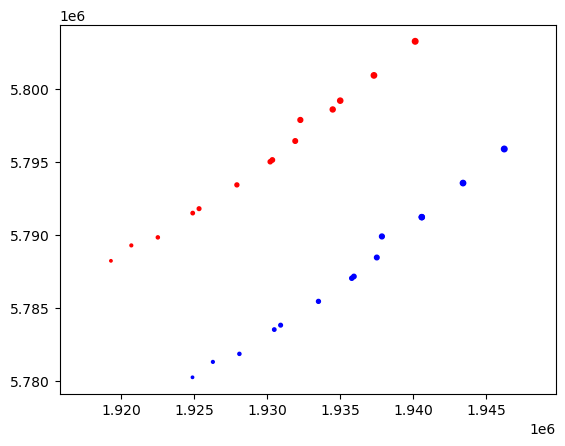

In [4]:
crustal_fault_model = "NZSHM22_InversionSolution-QXV0b21hdGlvblRhc2s6MTA3MDA2"
fault_name = "Edgecumbe"
# fault_name = "Kaniere"

dip_addition = 0

# Identify fault sections
fault_polys = gpd.read_file(os.path.join("data", "crustal_solutions", crustal_fault_model, "ruptures", "fault_sections.geojson")).to_crs(epsg=2193)
fault_polys = fault_polys[fault_polys['FaultName'].str.contains(fault_name)]


row_dict = {}
fault_step = 15000
dips = []
for idx, row in fault_polys.iterrows():
    # if idx < 523:
    #     continue
    dip = row['DipDeg'] + dip_addition
    dips.append(row['DipDeg'])
    strike = 360 - row['DipDir']  # Convert dip direction to strike
    z = row['LowDepth'] * 1e3
    for x, y in zip(row.geometry.coords.xy[0][::-1], row.geometry.coords.xy[1][::-1]):
        top_depth = -row['UpDepth'] * 1e3
        if 0 not in row_dict.keys():
            row_dict[0] = np.array([]).reshape(-1, 3)
        row_dict[0] = np.vstack((row_dict[0], np.array([x, y, 0]).reshape(1, 3)))
        for ix, z_step in enumerate(list(np.arange(-fault_step, -z, -fault_step)) + [-z], 1):
            by = -(z_step - top_depth) / np.tan(np.radians(dip))
            base = np.array([0, by, -z]).reshape(1, 3)
            base_rot = rotz(base, strike)
            base_rot += np.array([x, y, 0]).reshape(1, 3)
            if ix not in row_dict.keys():
                row_dict[ix] = np.array([]).reshape(-1, 3)
            row_dict[ix] = np.vstack((row_dict[ix], base_rot.reshape(1, 3)))

coords = np.array([]).reshape(-1, 3)
for level in row_dict.keys():
    row_dict[level] = np.unique(row_dict[level], axis=0)
    coords = np.vstack((coords, row_dict[level]))

plt.scatter(row_dict[0][:, 0], row_dict[0][:, 1], s=np.arange(row_dict[0].shape[0])+3, c='b', zorder=1)
for level in list(row_dict.keys())[1:]:
    print(level, row_dict.keys())
    plt.scatter(row_dict[level][:, 0], row_dict[level][:, 1], s=np.arange(row_dict[level].shape[0])+3, c='r', zorder=1)
plt.axis('equal')


[[ 1 15 14]
 [ 1 14  0]
 [ 1  2 15]
 [ 2  3 17]
 [ 3 18 17]
 [ 5  6 20]
 [ 5 18  4]
 [ 5 19 18]
 [ 6  7 20]
 [ 7 21 20]
 [ 7  8 22]
 [ 8 23 22]
 [10 25 24]
 [11 25 10]
 [12 25 11]
 [15  2 16]
 [16  2 17]
 [18  3  4]
 [19  5 20]
 [21  7 22]
 [23  9 10]
 [23 10 24]
 [23  8  9]
 [25 12 26]
 [26 12 27]
 [27 12 13]]


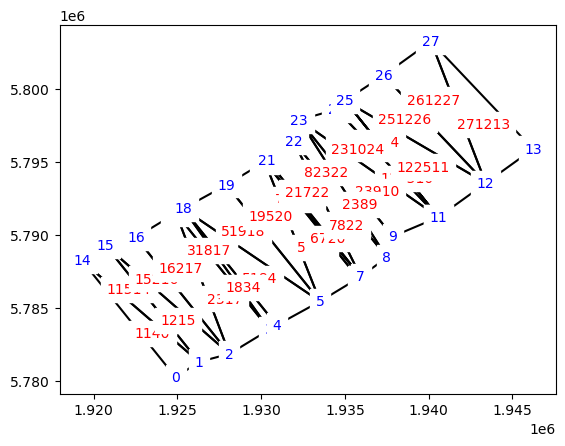

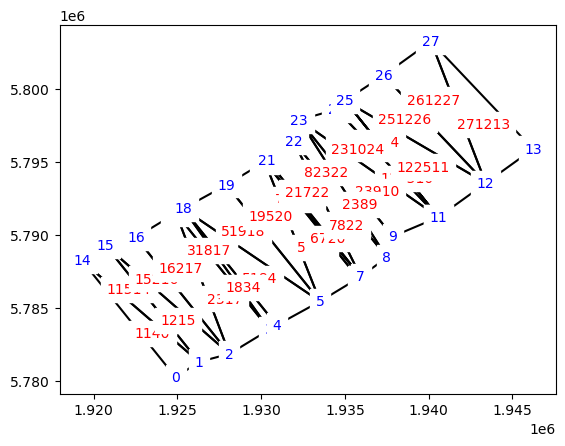

In [5]:
### Triangulate the fault surface
levels = row_dict.keys()

# Use delaunay triangulation (but on a smooth plane to assign corners to triangles)
delaun = np.zeros_like(coords[:, :2])
n_ix = 0
for ix, level in enumerate(levels):
    n_points = row_dict[level].shape[0]
    delaun[n_ix:n_ix+n_points, 0] = np.linspace(0, 1, n_points)
    delaun[n_ix:n_ix+n_points, 1] = ix
    n_ix += n_points

mesh = Delaunay(delaun).simplices
mesh = mesh[mesh[:, 0].argsort()]
print(mesh)
triangles = coords[mesh]

for ix, tri in enumerate(triangles):
    plt.plot(tri[[0, 1, 2, 0], 0], tri[[0, 1, 2, 0], 1], 'k-', zorder=0)
    tri = np.average(tri, axis=0)
    plt.text(tri[0], tri[1], ''.join([str(vertex) for vertex in mesh[ix, :]]), color='red', va='center', ha='center', backgroundcolor='white')
for ix, point in enumerate(coords):
    plt.text(point[0], point[1], str(ix), color='blue', va='center', ha='center', backgroundcolor='white')
plt.show()

triangles = np.array([check_triangle_normal(triangle) for triangle in triangles])

for ix, tri in enumerate(triangles):
    plt.plot(tri[[0, 1, 2, 0], 0], tri[[0, 1, 2, 0], 1], 'k-', zorder=0)
    tri = np.average(tri, axis=0)
    plt.text(tri[0], tri[1], ''.join([str(vertex) for vertex in mesh[ix, :]]), color='red', va='center', ha='center', backgroundcolor='white')
for ix, point in enumerate(coords):
    plt.text(point[0], point[1], str(ix), color='blue', va='center', ha='center', backgroundcolor='white')
plt.show()

In [6]:
# Build fault grid
center = row_dict[0].mean(axis=0)
grid_size = 50  # 100km
lons = np.arange(-grid_size / 2, grid_size / 2 + 1, 1) * 1e3 + center[0]
lats = np.arange(-grid_size / 2, grid_size / 2 + 1, 1) * 1e3 + center[1]
xx, yy = np.meshgrid(lons, lats)
obs_points = np.vstack((xx.ravel(), yy.ravel())).T
obs_points = np.hstack((obs_points, np.zeros((obs_points.shape[0], 1))))  # Set observation depth to 0

slip_array = np.zeros_like(triangles[:, :, 0])
normal = True
slip_array[:, 1] = 1.0  # 1m of dip-slip on all fault triangles
if normal:
    slip_array[:, 1] = -1.0  # Set dipslip to normal
# slip_array[:, 0] = 1.0  # 1m of strike-slip on all fault triangles

disp = HS.disp_free(obs_pts=obs_points, tris=triangles, slips=slip_array, nu=0.25)
print(f'mean: {disp[:, 2].mean()}')
print(f'max: {disp[:, 2].max()}')
print(f'min: {disp[:, 2].min()}')

mean: -0.03507342159485298
max: 0.16310542733932945
min: -0.6489815899455298


c:\Users\jmc753\AppData\Local\anaconda3\envs\jack\lib\site-packages\cutde\coordinators.py:77: UserWarning: The obs_pts input array has Fortran ordering. Converting to C ordering. This may be expensive.
  warnings.warn(


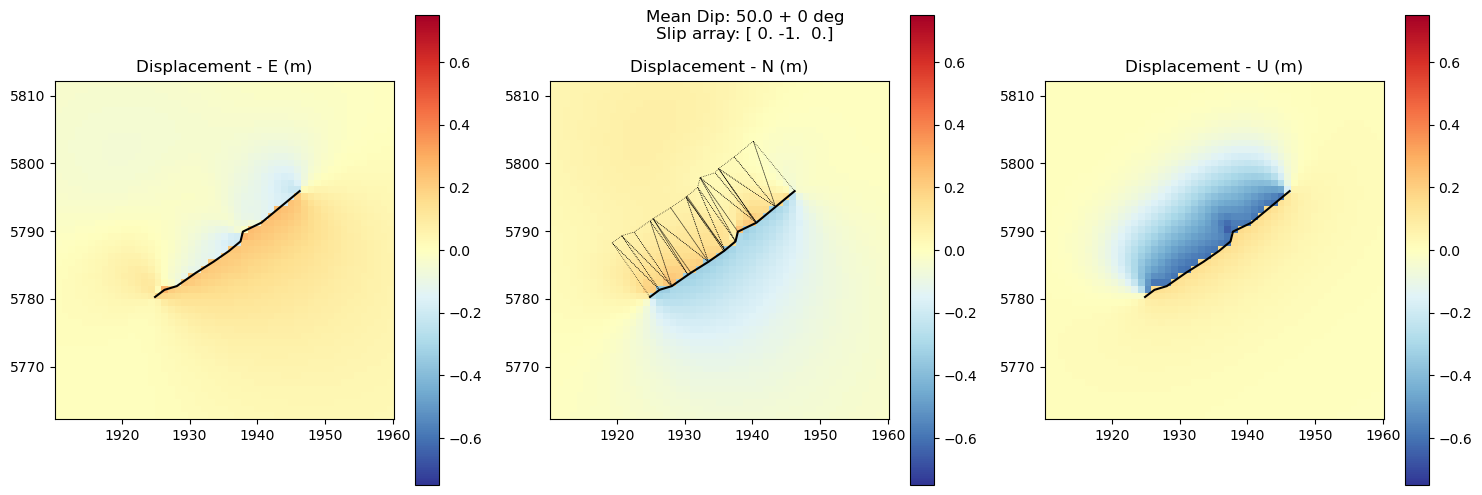

In [7]:
fig, axes = plt.subplots(1,3, figsize=(15, 5))
for ix, (ax, label) in enumerate(zip(axes, ['E', 'N', 'U'])):
    vmax = max([np.percentile(np.abs(disp[:,ix]), 99.5), 0.75])

    disp_array = disp[:, ix].reshape(xx.shape)
    im = ax.imshow(disp_array, extent=(lons.min() / 1e3, lons.max() / 1e3, lats.min() / 1e3, lats.max() / 1e3), vmin=-vmax, vmax=vmax, origin='lower', cmap='RdYlBu_r')
    ax.plot(row_dict[0][:, 0] / 1e3, row_dict[0][:, 1] / 1e3, 'k', markersize=2)
    fig.colorbar(im, ax=ax)
    ax.set_title(f'Displacement - {label} (m)')
    if ix == 1:
        for triangle in triangles:
            ax.plot(triangle[[0, 1, 2, 0], 0] * 1e-3, triangle[[0, 1, 2, 0], 1] * 1e-3, 'k:', zorder=0, linewidth=0.5)

plt.tight_layout()
if dip_addition < 0:
    dip_str = f'_m{abs(dip_addition)}'
else:
    dip_str = f'_p{dip_addition}'
plt.suptitle(f"Mean Dip: {np.mean(dips):.1f} + {dip_addition} deg\nSlip array: {slip_array[0]}")
plt.savefig(f'{fault_name.replace(" ","-")}_displacement_dip{dip_str}_{int(fault_step / 1000)}km.png', dpi=300) 
plt.show()

 